In [ ]:
!pip install patchify

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 47.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is inco

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gallo33henrique/sentinel-2-satellite-imagery")

print("Path to dataset files:", path)

100%|██████████| 2.02G/2.02G [01:34<00:00, 23.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gallo33henrique/sentinel-2-satellite-imagery/versions/1


In [ ]:
import os
path = "/root/.cache/kagglehub/datasets/gallo33henrique/sentinel-2-satellite-imagery/versions/1"
os.listdir(path)

['sentinel_2', 'EuroSAT']

In [ ]:
eurosat_images_path = os.path.join(path, "EuroSAT", "2750")
os.listdir(eurosat_images_path)

['Highway',
 'Industrial',
 'Forest',
 'HerbaceousVegetation',
 'AnnualCrop',
 'Pasture',
 'SeaLake',
 'PermanentCrop',
 'Residential',
 'River']

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping


# Vision Transformer

In [ ]:
class ClassToken(Layer):
  def __init__(self):
    super().__init__()

  def build(self, input_shape):
    w_init = tf.random_normal_initializer()
    self.w = tf.Variable(
        initial_value = w_init(shape=(1, 1, input_shape[-1]), dtype=tf.float32),
        trainable = True
    )

  def call(self, inputs):
    batch_size = tf.shape(inputs)[0]
    hidden_dim = self.w.shape[-1]

    cls = tf.broadcast_to(self.w, [batch_size, 1, hidden_dim])
    cls = tf.cast(cls, dtype=inputs.dtype)
    return cls



## MLP

O Multi-Layer Perceptron (MLP) é a arquitetura clássica de rede neural artificial "feedforward" (onde a informação flui apenas para frente), sendo composto por 3 tipos de camadas de neuronios:

- Input  Layer
- Hidden Layer
- Output Layer



In [ ]:
def mlp(x, cf):
    x = Dense(cf["mlp_dim"], activation="gelu")(x)
    x = Dropout(cf["dropout_rate"])(x)
    x = Dense(cf["hidden_dim"])(x)
    x = Dropout(cf["dropout_rate"])(x)
    return x

## Transformer Enconder

Recebe uma sequencia de vetores contendo o class token + embedded patches, e
é processada atraves de uma serie de camadas de transformer onde cada uma consiste multi-headed self-attention, dessa forma decidindo quais caracteristicas deve ser priorizadas

In [ ]:
def transformer_encoder(x, cf):
    skip_1 = x
    x = LayerNormalization()(x)
    x = MultiHeadAttention(
        num_heads=cf["num_heads"], key_dim=cf["hidden_dim"]
    )(x, x)
    x = Add()([x, skip_1])

    skip_2 = x
    x = LayerNormalization()(x)
    x = mlp(x, cf)
    x = Add()([x, skip_2])

    return x

In [ ]:
def ViT(cf):
    # Entrada, recebendo uma sequencia representada por patchs de 16x16
    input_shape = (cf["num_patches"], cf["patch_size"]*cf["patch_size"]*cf["num_channels"])
    inputs = Input(input_shape)

    # A canada Dense projeta os pixels brutos para um espaco latente de maior dimentao
    patch_embed = Dense(cf["hidden_dim"])(inputs)
    # Durante o processamento paralelo e necessario saber a ordenacao do patch par isso e criado um indice para que
    # assim seja possivel orientar a correlacao entre vetor e posicao
    positions = tf.range(start=0, limit=cf["num_patches"], delta=1)
    pos_embed = Embedding(input_dim=cf["num_patches"], output_dim=cf["hidden_dim"])(positions)
    embed = patch_embed + pos_embed

    # Similar ao BERT, e adicionado um neuronio especial ao inicio da sequencia para que assim ao
    # longo do aprendizado esse token absorva o contexto geral da imagem
    token = ClassToken()(embed)
    x = Concatenate(axis=1)([token, embed])

    # Laço de treinamento do transformer
    for _ in range(cf["num_layers"]):
        x = transformer_encoder(x, cf)

    # Normalizacao, O modelo ignora todos os patches originais da imagem e extrai apenas
    # o primeiro elemento da sequência: o Class Token.
    # O Class Token (que agora contém o resumo da imagem) passa por uma camada densa final para dizer a qual classe pertence

    x = LayerNormalization()(x)
    x = x[:, 0, :]
    x = Dense(cf["num_classes"], activation="softmax")(x)

    model = Model(inputs, x)
    return model

# Preparando o dado para o treinamento

## Definindo os hiperparametros

In [ ]:
hp = {}
hp["image_size"] = 64
hp["num_channels"] = 3 # RGB
hp["patch_size"] = 16 # Ajustar de acordo com o tamaho da imagem
hp["num_patches"] = (hp["image_size"]**2) // (hp["patch_size"]**2)
hp["flat_patches_shape"] = (hp["num_patches"], hp["patch_size"]*hp["patch_size"]*hp["num_channels"])

hp["batch_size"] = 16
hp["lr"] = 1e-4
hp["num_epochs"] = 10
hp["num_classes"] = 10
hp["class_names"] =[
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
 ]

hp["num_layers"] = 6
hp["hidden_dim"] = 256
hp["mlp_dim"] = 1024
hp["num_heads"] = 4
hp["dropout_rate"] = 0.1

In [ ]:
from glob import glob
import os
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

def load_data(path, split=0.1):
    images = shuffle(glob(os.path.join(path, "*", "*.jpg")))

    split_size = int(len(images) * split)
    train_x, valid_x = train_test_split(images, test_size=split_size, random_state=42)
    train_x, test_x = train_test_split(train_x, test_size=split_size, random_state=42)

    return train_x, valid_x, test_x

In [ ]:
import cv2
import numpy as np
from patchify import patchify

def process_image_label(path):
    image = cv2.imread(path)
    image = cv2.resize(image, (hp["image_size"], hp["image_size"]))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = image / 255.0

    patch_shape = (hp["patch_size"], hp["patch_size"], hp["num_channels"])
    patches = patchify(image, patch_shape, hp["patch_size"])
    patches = np.reshape(patches, hp["flat_patches_shape"])
    patches = patches.astype(np.float32)

    label = os.path.basename(os.path.dirname(path))
    label = label.decode('utf-8')
    class_idx = hp["class_names"].index(label)
    class_idx = np.array(class_idx, dtype=np.int32)

    return patches, class_idx

def parse(path):
    patches, labels = tf.numpy_function(process_image_label, [path], [tf.float32, tf.int32])
    labels = tf.one_hot(labels, hp["num_classes"])

    patches.set_shape(hp["flat_patches_shape"])
    labels.set_shape(hp["num_classes"])

    return patches, labels

In [ ]:
def tf_dataset(images, batch=32):
    ds = tf.data.Dataset.from_tensor_slices((images))
    ds = ds.map(parse).batch(batch).prefetch(8)
    return ds

## Treinando o modelo

In [ ]:
model_dir = os.path.join("/content","files")
os.makedirs(model_dir, exist_ok=True)

In [ ]:
model_path = os.path.join("files", "model.h5")
csv_path = os.path.join("files", "log.csv")

In [ ]:
callbacks = [
    ModelCheckpoint(model_path, monitor='val_loss', verbose=1, save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10, min_lr=1e-10, verbose=1),
    CSVLogger(csv_path),
    EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=False),
]

In [ ]:
model = ViT(hp)
model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(hp["lr"], clipvalue=1.0),
    metrics=["acc"]
)

In [ ]:
train_x, valid_x, test_x = load_data(eurosat_images_path)
print(f"Train: {len(train_x)} - Valid: {len(valid_x)} - Test: {len(test_x)}")

train_ds = tf_dataset(train_x, batch=hp["batch_size"])
valid_ds = tf_dataset(valid_x, batch=hp["batch_size"])
test_ds = tf_dataset(test_x, batch=hp["batch_size"])

Train: 21600 - Valid: 2700 - Test: 2700


In [ ]:
model.fit(
    train_ds,
    epochs=hp["num_epochs"],
    validation_data=valid_ds,
    callbacks=callbacks
)

Epoch 1/10
1349/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.3840 - loss: 1.6906
Epoch 1: val_loss improved from inf to 1.10518, saving model to files/model.h5


1350/1350 ━━━━━━━━━━━━━━━━━━━━ 73s 29ms/step - acc: 0.3842 - loss: 1.6901 - val_acc: 0.6052 - val_loss: 1.1052 - learning_rate: 1.0000e-04
Epoch 2/10
1349/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.6333 - loss: 1.0108
Epoch 2: val_loss improved from 1.10518 to 1.02170, saving model to files/model.h5


1350/1350 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - acc: 0.6333 - loss: 1.0108 - val_acc: 0.6296 - val_loss: 1.0217 - learning_rate: 1.0000e-04
Epoch 3/10
1349/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.6822 - loss: 0.8655
Epoch 3: val_loss improved from 1.02170 to 0.76958, saving model to files/model.h5


1350/1350 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - acc: 0.6822 - loss: 0.8655 - val_acc: 0.7215 - val_loss: 0.7696 - learning_rate: 1.0000e-04
Epoch 4/10
1349/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.7288 - loss: 0.7526
Epoch 4: val_loss improved from 0.76958 to 0.75363, saving model to files/model.h5


1350/1350 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - acc: 0.7288 - loss: 0.7526 - val_acc: 0.7233 - val_loss: 0.7536 - learning_rate: 1.0000e-04
Epoch 5/10
1349/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.7491 - loss: 0.6951
Epoch 5: val_loss improved from 0.75363 to 0.70909, saving model to files/model.h5


1350/1350 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - acc: 0.7491 - loss: 0.6950 - val_acc: 0.7441 - val_loss: 0.7091 - learning_rate: 1.0000e-04
Epoch 6/10
1349/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.7722 - loss: 0.6474
Epoch 6: val_loss did not improve from 0.70909
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - acc: 0.7722 - loss: 0.6473 - val_acc: 0.7207 - val_loss: 0.8180 - learning_rate: 1.0000e-04
Epoch 7/10
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.7831 - loss: 0.6035
Epoch 7: val_loss did not improve from 0.70909
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - acc: 0.7831 - loss: 0.6035 - val_acc: 0.7015 - val_loss: 0.9010 - learning_rate: 1.0000e-04
Epoch 8/10
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.7951 - loss: 0.5773
Epoch 8: val_loss did not improve from 0.70909
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - acc: 0.7951 - loss: 0.5773 - val_acc: 0.7381 - val_loss: 0.7700 - learning_rate: 1.0000e-04
Epoch 9/10
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/s

1350/1350 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - acc: 0.8169 - loss: 0.5147 - val_acc: 0.7656 - val_loss: 0.6791 - learning_rate: 1.0000e-04


# Validando o modelo

In [ ]:
model = ViT(hp)
model.load_weights(model_path)
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    optimizer=tf.keras.optimizers.Adam(hp["lr"]),
    metrics=["acc"]
)

model.evaluate(test_ds)

169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - acc: 0.7657 - loss: 0.6558


[0.6936679482460022, 0.7562962770462036]

### Realizando Predições com o Modelo

In [ ]:
import numpy as np
import cv2
import tensorflow as tf
import os
from patchify import patchify

random_image_path = test_x[0]
print(f"Image selected for prediction: {random_image_path}")

def preprocess_single_image(image_path, hp):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (hp["image_size"], hp["image_size"]))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = image / 255.0

    patch_shape = (hp["patch_size"], hp["patch_size"], hp["num_channels"])
    patches = patchify(image, patch_shape, hp["patch_size"])
    patches = np.reshape(patches, hp["flat_patches_shape"])
    patches = patches.astype(np.float32)

    patches = np.expand_dims(patches, axis=0)
    return patches

preprocessed_image = preprocess_single_image(random_image_path, hp)
predictions = model.predict(preprocessed_image)

predicted_class_index = np.argmax(predictions[0])
confidence = predictions[0][predicted_class_index]

predicted_class_name = hp["class_names"][predicted_class_index]
true_label = os.path.basename(os.path.dirname(random_image_path))

print(f"\nTrue Label: {true_label}")
print(f"Predicted Class: {predicted_class_name}")
print(f"Confidence: {confidence:.4f}")

Image selected for prediction: /root/.cache/kagglehub/datasets/gallo33henrique/sentinel-2-satellite-imagery/versions/1/EuroSAT/2750/HerbaceousVegetation/HerbaceousVegetation_1899.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

True Label: HerbaceousVegetation
Predicted Class: HerbaceousVegetation
Confidence: 0.9859


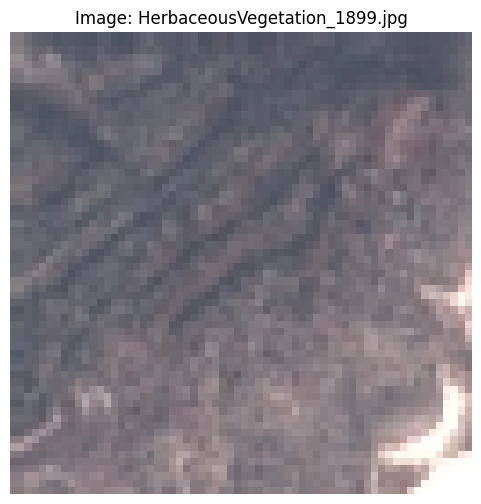

In [ ]:
import matplotlib.pyplot as plt
import cv2

image_to_display = cv2.imread(random_image_path)
image_to_display = cv2.cvtColor(image_to_display, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_to_display)
plt.title(f"Image: {os.path.basename(random_image_path)}")
plt.axis('off')
plt.show()

### Predição com uma Imagem Externa

In [ ]:
def predict_image(external_image_path, hp):

  preprocessed_external_image = preprocess_single_image(external_image_path, hp)


  external_predictions = model.predict(preprocessed_external_image)

  predicted_class_index_external = np.argmax(external_predictions[0])
  confidence_external = external_predictions[0][predicted_class_index_external]

  predicted_class_name_external = hp["class_names"][predicted_class_index_external]

  print(f"\nPredicted Class: {predicted_class_name_external}")
  print(f"Confidence: {confidence_external:.4f}")


  image_to_display_external = cv2.imread(external_image_path)
  image_to_display_external = cv2.cvtColor(image_to_display_external, cv2.COLOR_BGR2RGB)

  plt.figure(figsize=(6, 6))
  plt.imshow(image_to_display_external)
  plt.title(f"Image: {os.path.basename(external_image_path)}")
  plt.axis('off')
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Predicted Class: Industrial
Confidence: 0.5684


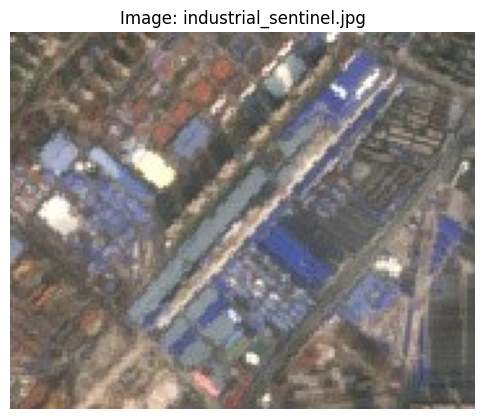

In [ ]:
predict_image("/content/industrial_sentinel.jpg", hp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step

Predicted Class: AnnualCrop
Confidence: 0.9958


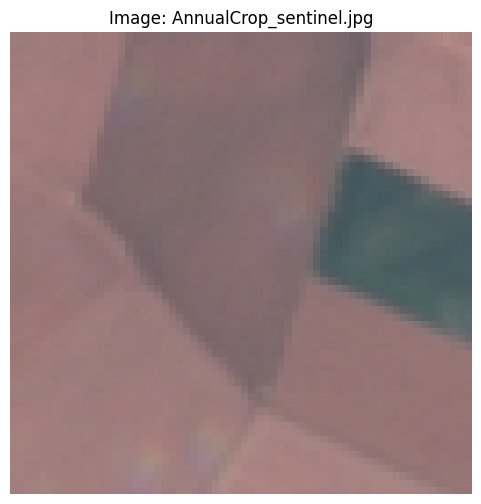

In [ ]:
predict_image("/content/AnnualCrop_sentinel.jpg", hp)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Predicted Class: HerbaceousVegetation
Confidence: 0.3644


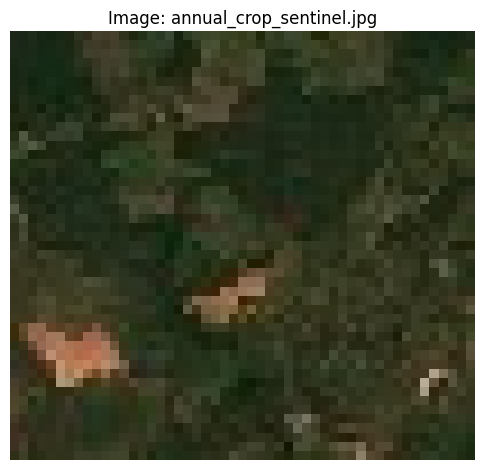

In [ ]:
predict_image("/content/annual_crop_sentinel.jpg", hp)
